#Import Libraries

In [1]:
# --- Core Libraries ---
import os
import math
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from scipy.stats import chi2_contingency

# --- Preprocessing ---
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV

# --- Models ---
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# --- Resampling ---
from imblearn.over_sampling import SMOTE

# --- Metrics ---
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, make_scorer
)

# --- Other ---
import pickle

# --- Config ---
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')


Load dataset

In [2]:
df = pd.read_csv('/content/bank.csv', sep=';')

First five rows

In [3]:
display(df.head())

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## Basic Exploratory Data Analysis (EDA)


In [4]:
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [5]:
display(df.describe())

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [6]:
display(df.isnull().sum())

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


No null values

In [7]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Numerical:", numerical_cols)
print("Categorical:", categorical_cols)

Numerical: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Categorical: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']


#Univariate Analysis

Numerical Features

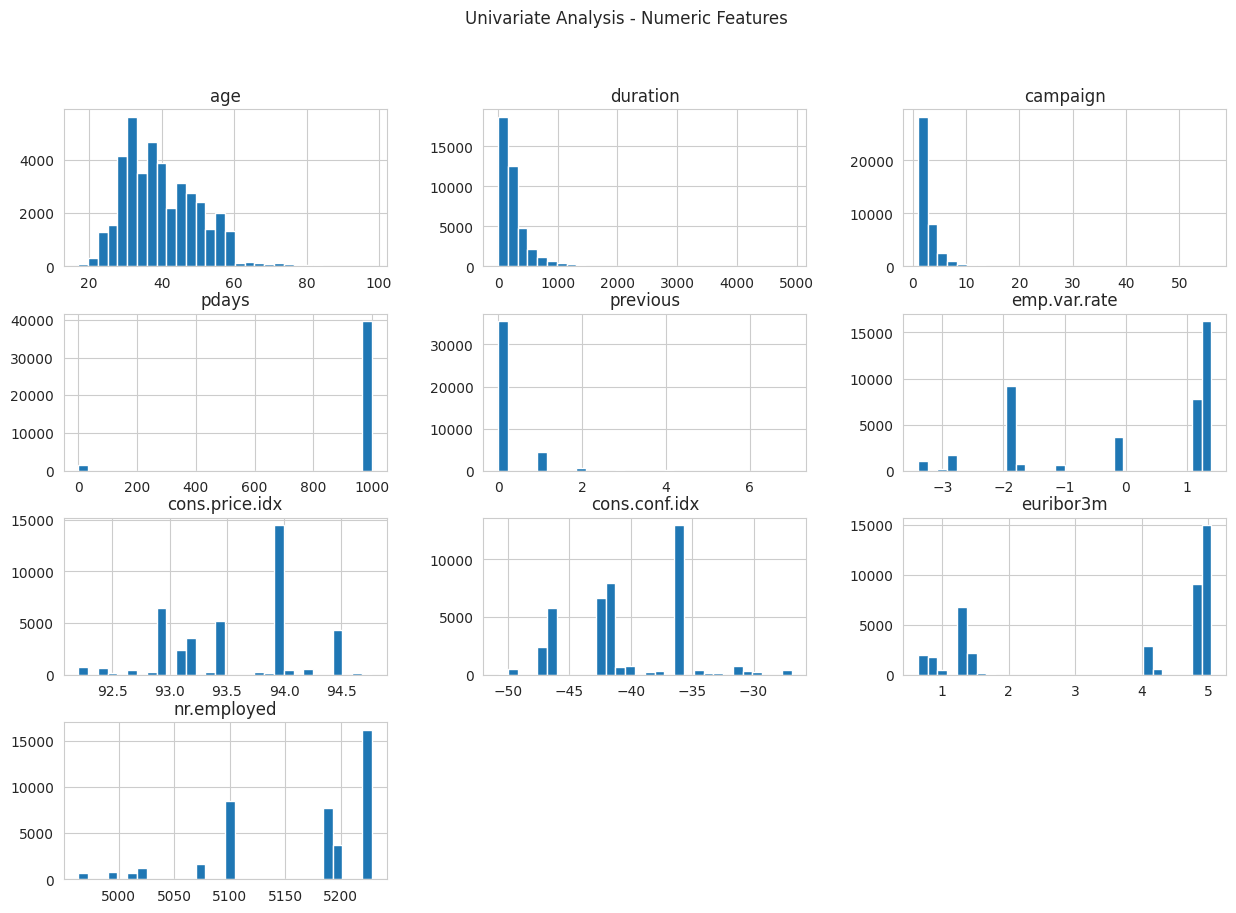

In [8]:
# Plot histograms
df[numerical_cols].hist(figsize=(15,10), bins=30)
plt.suptitle("Univariate Analysis - Numeric Features")
plt.show()

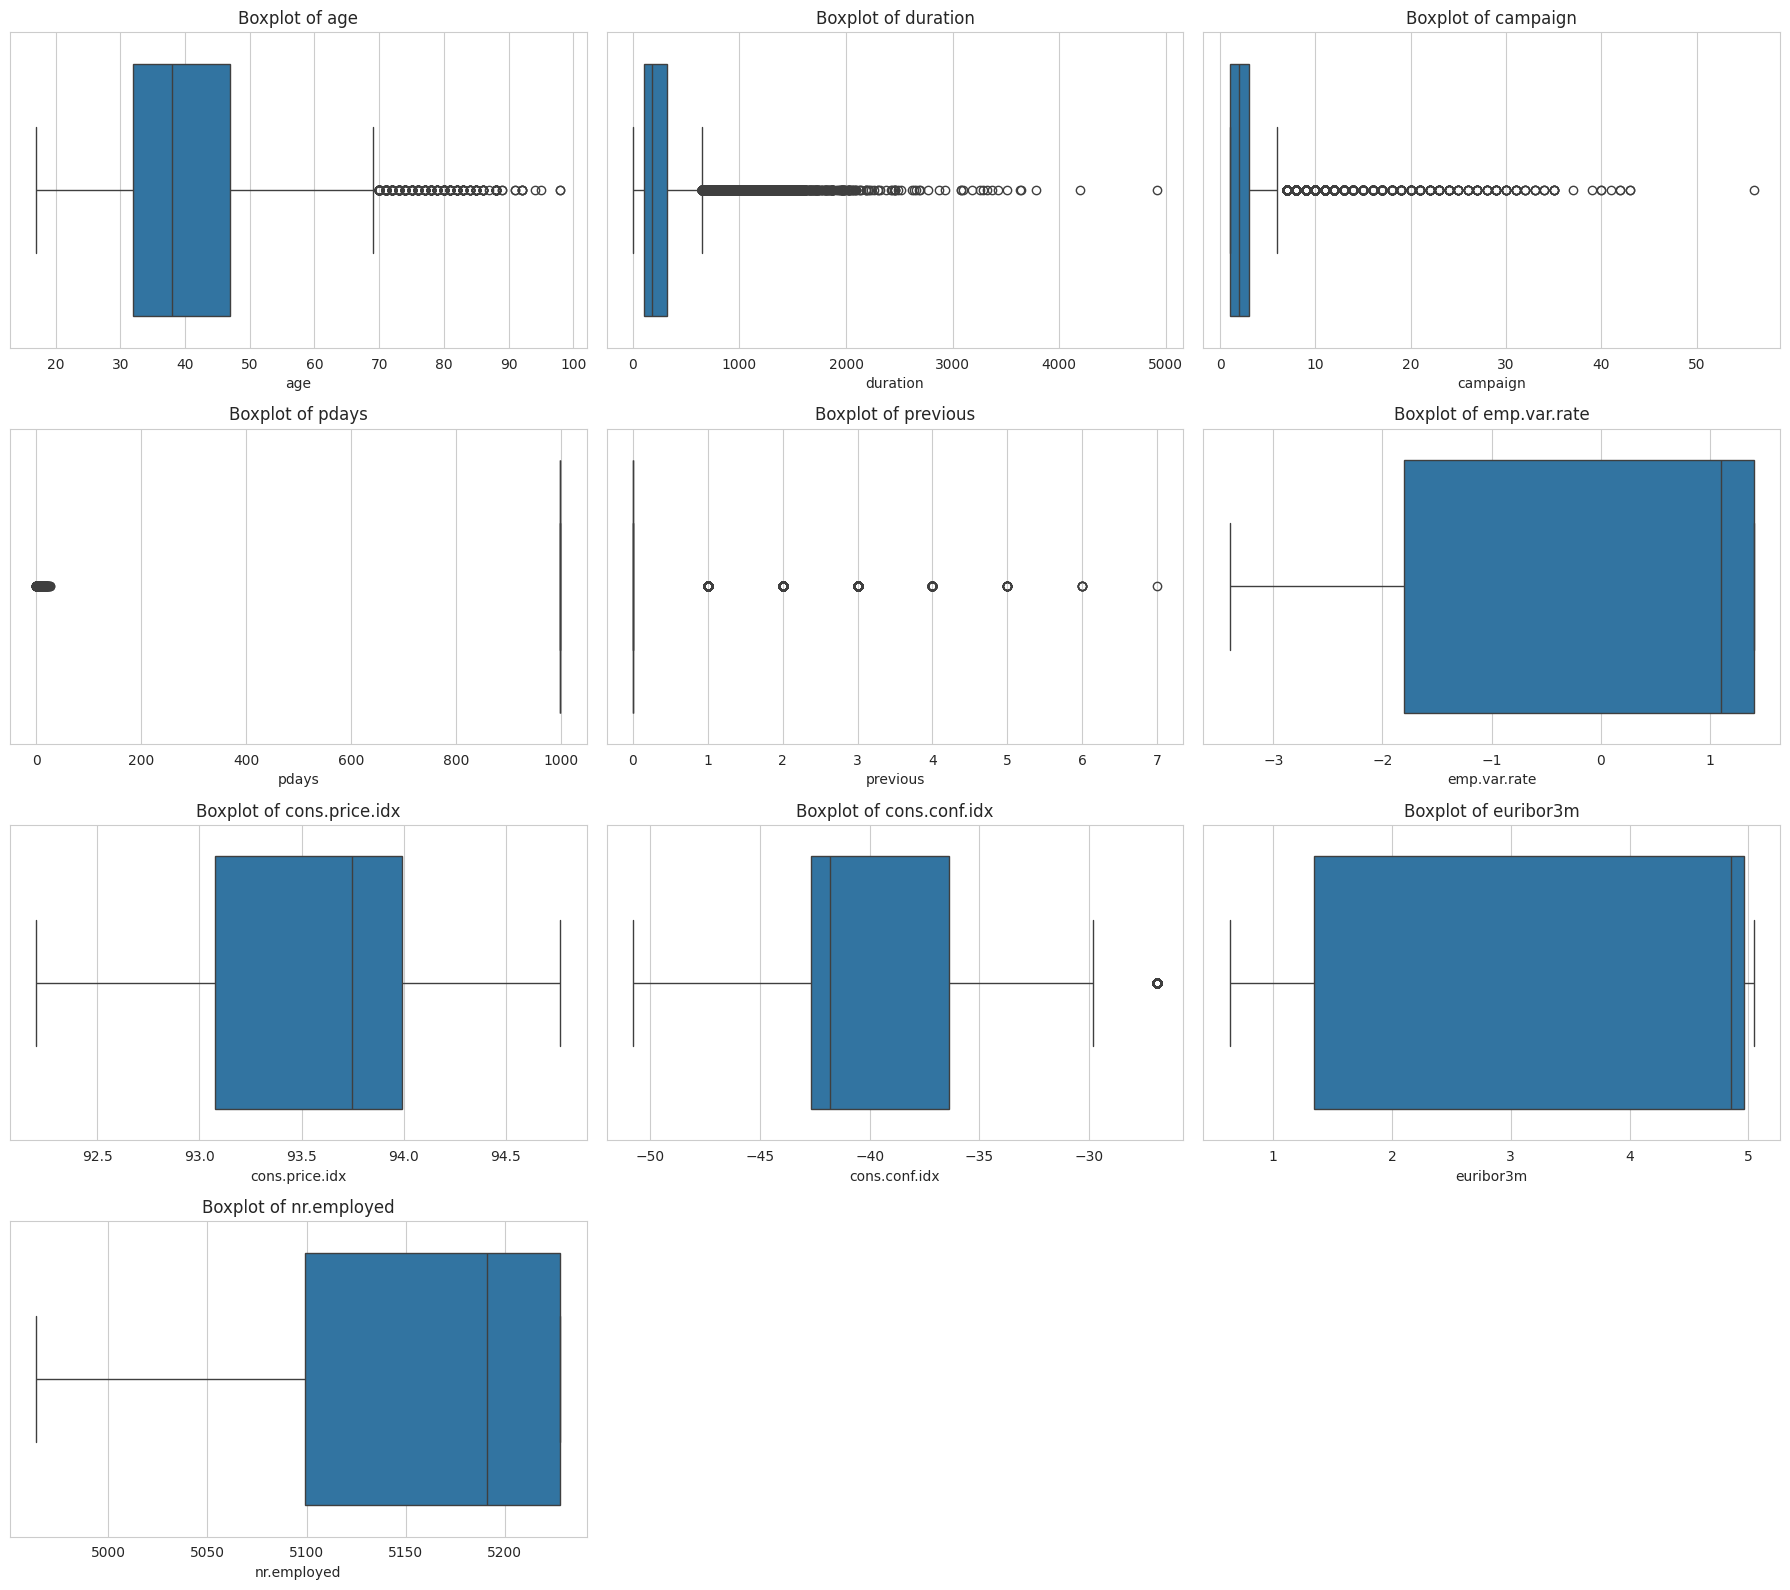

In [9]:
plt.figure(figsize=(18, 4 * math.ceil(len(numerical_cols) / 3)))  # Dynamic grid of boxplots
for i, col in enumerate(numerical_cols):
    plt.subplot(math.ceil(len(numerical_cols) / 3), 3, i + 1)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}', fontsize=12)
plt.tight_layout()
plt.show()


In [10]:
#Summary Statistics
print(df[numerical_cols].describe())

               age      duration      campaign         pdays      previous  \
count  41188.00000  41188.000000  41188.000000  41188.000000  41188.000000   
mean      40.02406    258.285010      2.567593    962.475454      0.172963   
std       10.42125    259.279249      2.770014    186.910907      0.494901   
min       17.00000      0.000000      1.000000      0.000000      0.000000   
25%       32.00000    102.000000      1.000000    999.000000      0.000000   
50%       38.00000    180.000000      2.000000    999.000000      0.000000   
75%       47.00000    319.000000      3.000000    999.000000      0.000000   
max       98.00000   4918.000000     56.000000    999.000000      7.000000   

       emp.var.rate  cons.price.idx  cons.conf.idx     euribor3m   nr.employed  
count  41188.000000    41188.000000   41188.000000  41188.000000  41188.000000  
mean       0.081886       93.575664     -40.502600      3.621291   5167.035911  
std        1.570960        0.578840       4.628198    

## Feature Distribution Summary

- **age:** Nearly symmetrical, slightly right-skewed (Mean ≈ 40, Median ≈ 38); most clients are aged 30–45 and no transformation is needed.  
- **duration:** Highly right-skewed with strong outliers (Max = 4918); requires log transformation or binning.  
- **campaign:** Right-skewed and zero-inflated (Max = 56); most clients contacted 1–3 times, extreme values should be capped.  
- **pdays:** Dominated by 999 values indicating no previous contact; should be treated as categorical.  
- **previous:** Strongly right-skewed with ≥75% zeros; non-zero entries form a small distinct segment.  
- **emp.var.rate:** Discrete and multi-modal (e.g., -1.8, 1.4); best handled as ordinal or categorical.  
- **euribor3m:** Multi-modal with peaks near 1 and 4.9; reflects economic cycles, likely a strong predictor.  
- **nr.employed:** Discrete and tightly clustered (~72 std); behaves like a categorical feature.  
- **cons.price.idx:** Narrow range (92.2–94.7) with low variance (~0.58); limited predictive impact.


Categoricals Variables

In [11]:
#Counts and proportion represente by each category
for col in categorical_cols:
    print(f"--- Frequencies for {col} ---")
    print(df[col].value_counts()) # Raw Counts

    print(f"\n--- Proportions for {col} ---")
    print(df[col].value_counts(normalize=True).mul(100).round(2).astype(str) + '%') # Percentages
    print("\n")

--- Frequencies for job ---
job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64

--- Proportions for job ---
job
admin.            25.3%
blue-collar      22.47%
technician       16.37%
services          9.64%
management         7.1%
retired           4.18%
entrepreneur      3.54%
self-employed     3.45%
housemaid         2.57%
unemployed        2.46%
student           2.12%
unknown            0.8%
Name: proportion, dtype: object


--- Frequencies for marital ---
marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64

--- Proportions for marital ---
marital
married     60.52%
single      28.09%
divorced     11.2%
unknown      0.19%
Name: proportion, dtype: object


--- Frequencies for ed

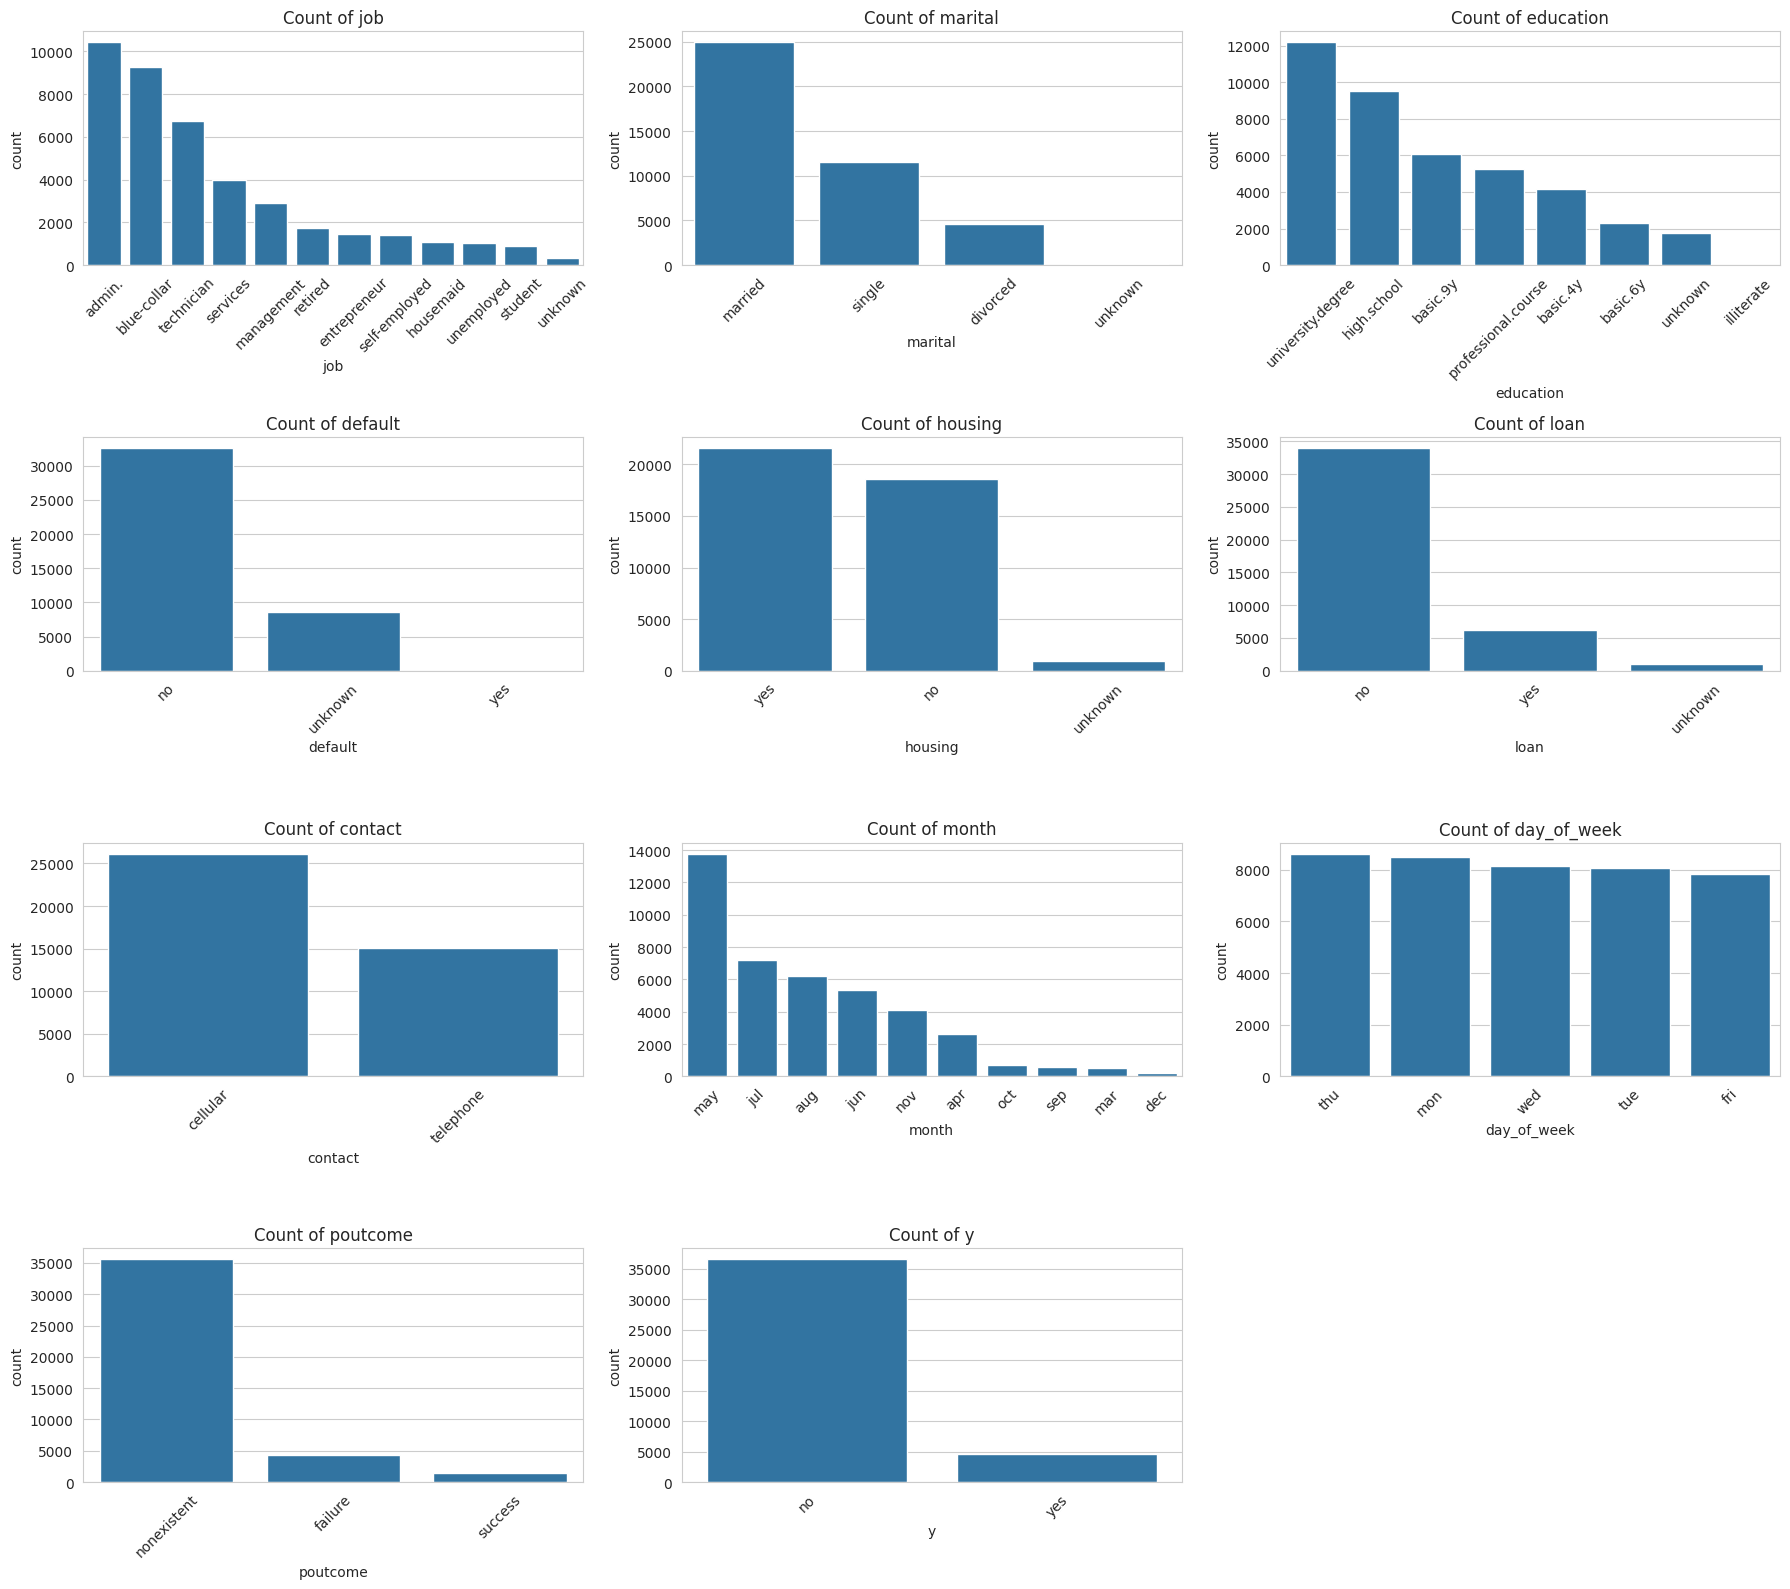

In [12]:
#Bar plots
plt.figure(figsize=(18, 4 * math.ceil(len(categorical_cols) / 3)))  # Dynamic grid of bar plots
for i, col in enumerate(categorical_cols):
    plt.subplot(math.ceil(len(categorical_cols) / 3), 3, i + 1)
    sns.countplot(x=col, data=df, order=df[col].value_counts().index)
    plt.xticks(rotation=45)
    plt.title(f'Count of {col}', fontsize=12)
plt.tight_layout()
plt.show()


## Categorical Feature Summary

- **Target (y):** Imbalanced — 88.7% ‘no’, 11.3% ‘yes’; models may overfit to ‘no’, so F1/ROC-AUC or resampling is preferred.  
- **job:** Dominated by admin., blue-collar, technician, and services roles.  
- **marital:** ~60% married, followed by single and divorced.  
- **education:** Mostly university, high.school, and basic.9y categories.  
- **housing:** Fairly balanced — yes (52%), no (45%).  
- **loan:** ‘no’ dominates (82%).  
- **default:** 81% no, 18% unknown, few yes.  
- **contact:** 63% cellular, remaining are telephone or unknown.  
- **month:** Activity peaks during May–August; other months contribute <2%.  
- **day_of_week:** Evenly distributed (~20% each).  
- **poutcome:** 86% nonexistent, 3% success, rest failure or other outcomes.


#Bivariate Analysis

Numerical vs Target

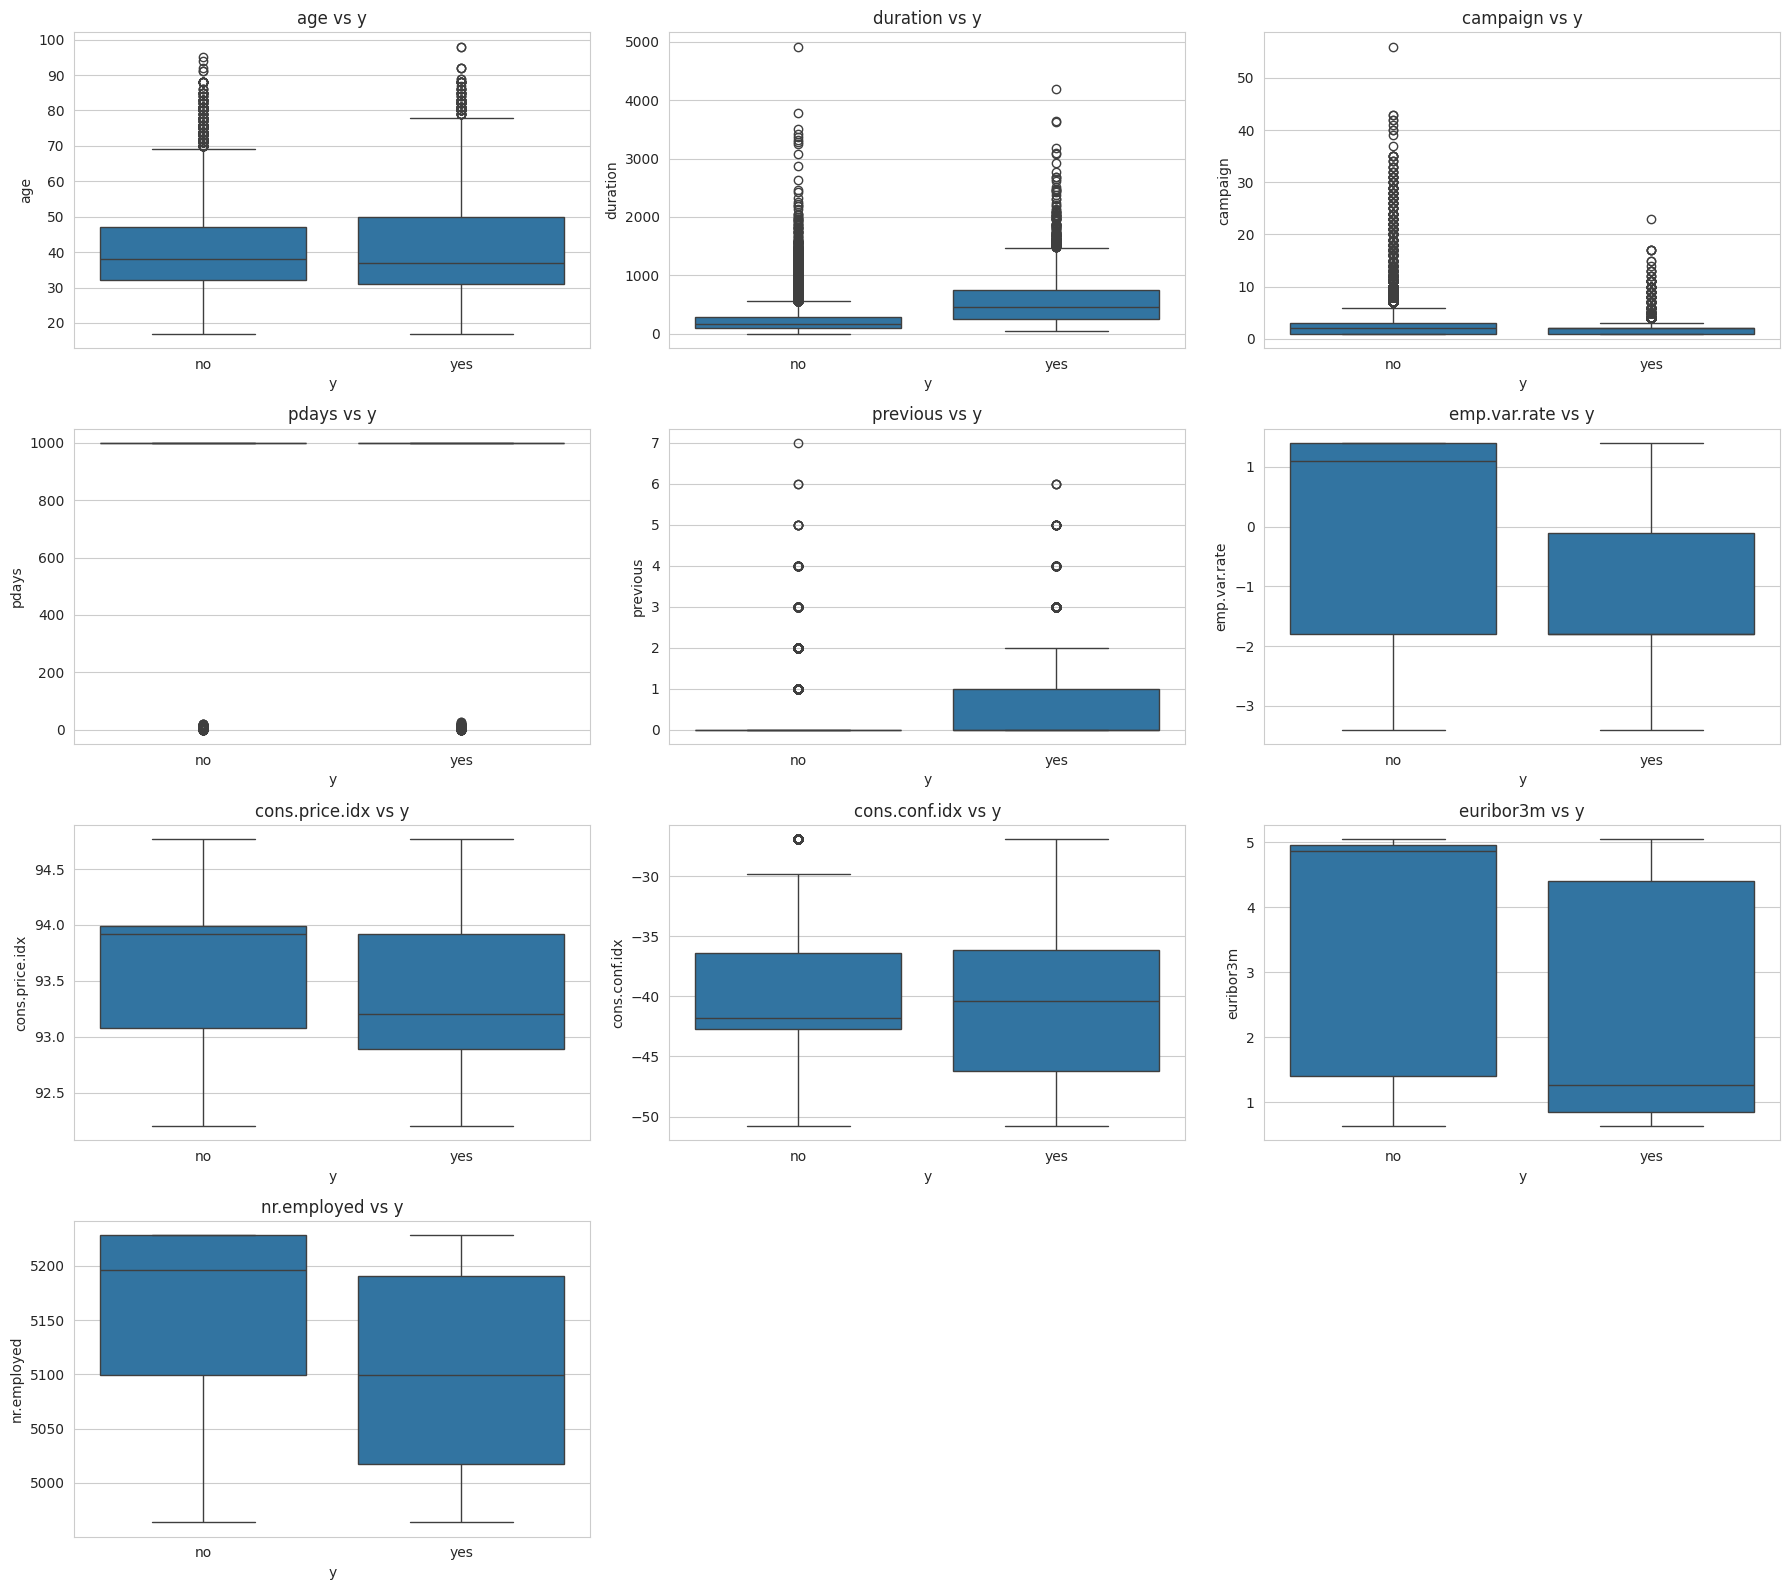

In [13]:
# Boxplots of numerical features vs target
plt.figure(figsize=(18, 4 * -(-len(numerical_cols)//3)))
for i, col in enumerate(numerical_cols):
    plt.subplot(-(-len(numerical_cols)//3), 3, i + 1)
    sns.boxplot(x='y', y=col, data=df)
    plt.title(f'{col} vs y')
plt.tight_layout(); plt.show()


## Predictor Strength Summary

**Strong Predictors (clear separation):**
- **duration:** Much higher for *y = ‘yes’*; longer calls strongly correlate with success.  
- **pdays:** *y = ‘yes’* concentrated near 0 → recently contacted; *y = ‘no’* near 999 → not contacted.  
- **previous:** Slightly higher for *y = ‘yes’*; repeat contacts improve conversion chances.  
- **emp.var.rate:** Lower (negative) for *y = ‘yes’*; success more likely during weaker economic periods.  
- **euribor3m:** Lower for *y = ‘yes’*; low interest rates favor subscriptions.  
- **nr.employed:** Lower for *y = ‘yes’*; fewer employed correlates with higher success.  

**Weak Predictors (heavy overlap):**
- **age:** Nearly identical distributions → weak predictor.  
- **campaign:** Similar medians and spread → minimal impact.  
- **cons.price.idx:** Strong overlap → low predictive power.  
- **cons.conf.idx:** Almost identical for both classes → weak indicator.


Categorical vs Target


In [14]:

for col in categorical_cols:
    print(f"\n--- Analysis for Feature: {col} ---")

    # 1. Counts
    print("Raw Counts:")
    contingency_table = pd.crosstab(df[col], df['y'])
    print(contingency_table)

    # 2. Proportions
    # % for yes and no
    print("\nProportions (Rows sum to 1.0 - Good for Classification):")
    proportions = pd.crosstab(df[col], df['y'], normalize='index').mul(100).round(2)
    print(proportions)


--- Analysis for Feature: job ---
Raw Counts:
y                no   yes
job                      
admin.         9070  1352
blue-collar    8616   638
entrepreneur   1332   124
housemaid       954   106
management     2596   328
retired        1286   434
self-employed  1272   149
services       3646   323
student         600   275
technician     6013   730
unemployed      870   144
unknown         293    37

Proportions (Rows sum to 1.0 - Good for Classification):
y                 no    yes
job                        
admin.         87.03  12.97
blue-collar    93.11   6.89
entrepreneur   91.48   8.52
housemaid      90.00  10.00
management     88.78  11.22
retired        74.77  25.23
self-employed  89.51  10.49
services       91.86   8.14
student        68.57  31.43
technician     89.17  10.83
unemployed     85.80  14.20
unknown        88.79  11.21

--- Analysis for Feature: marital ---
Raw Counts:
y            no   yes
marital              
divorced   4136   476
married   22396  2532


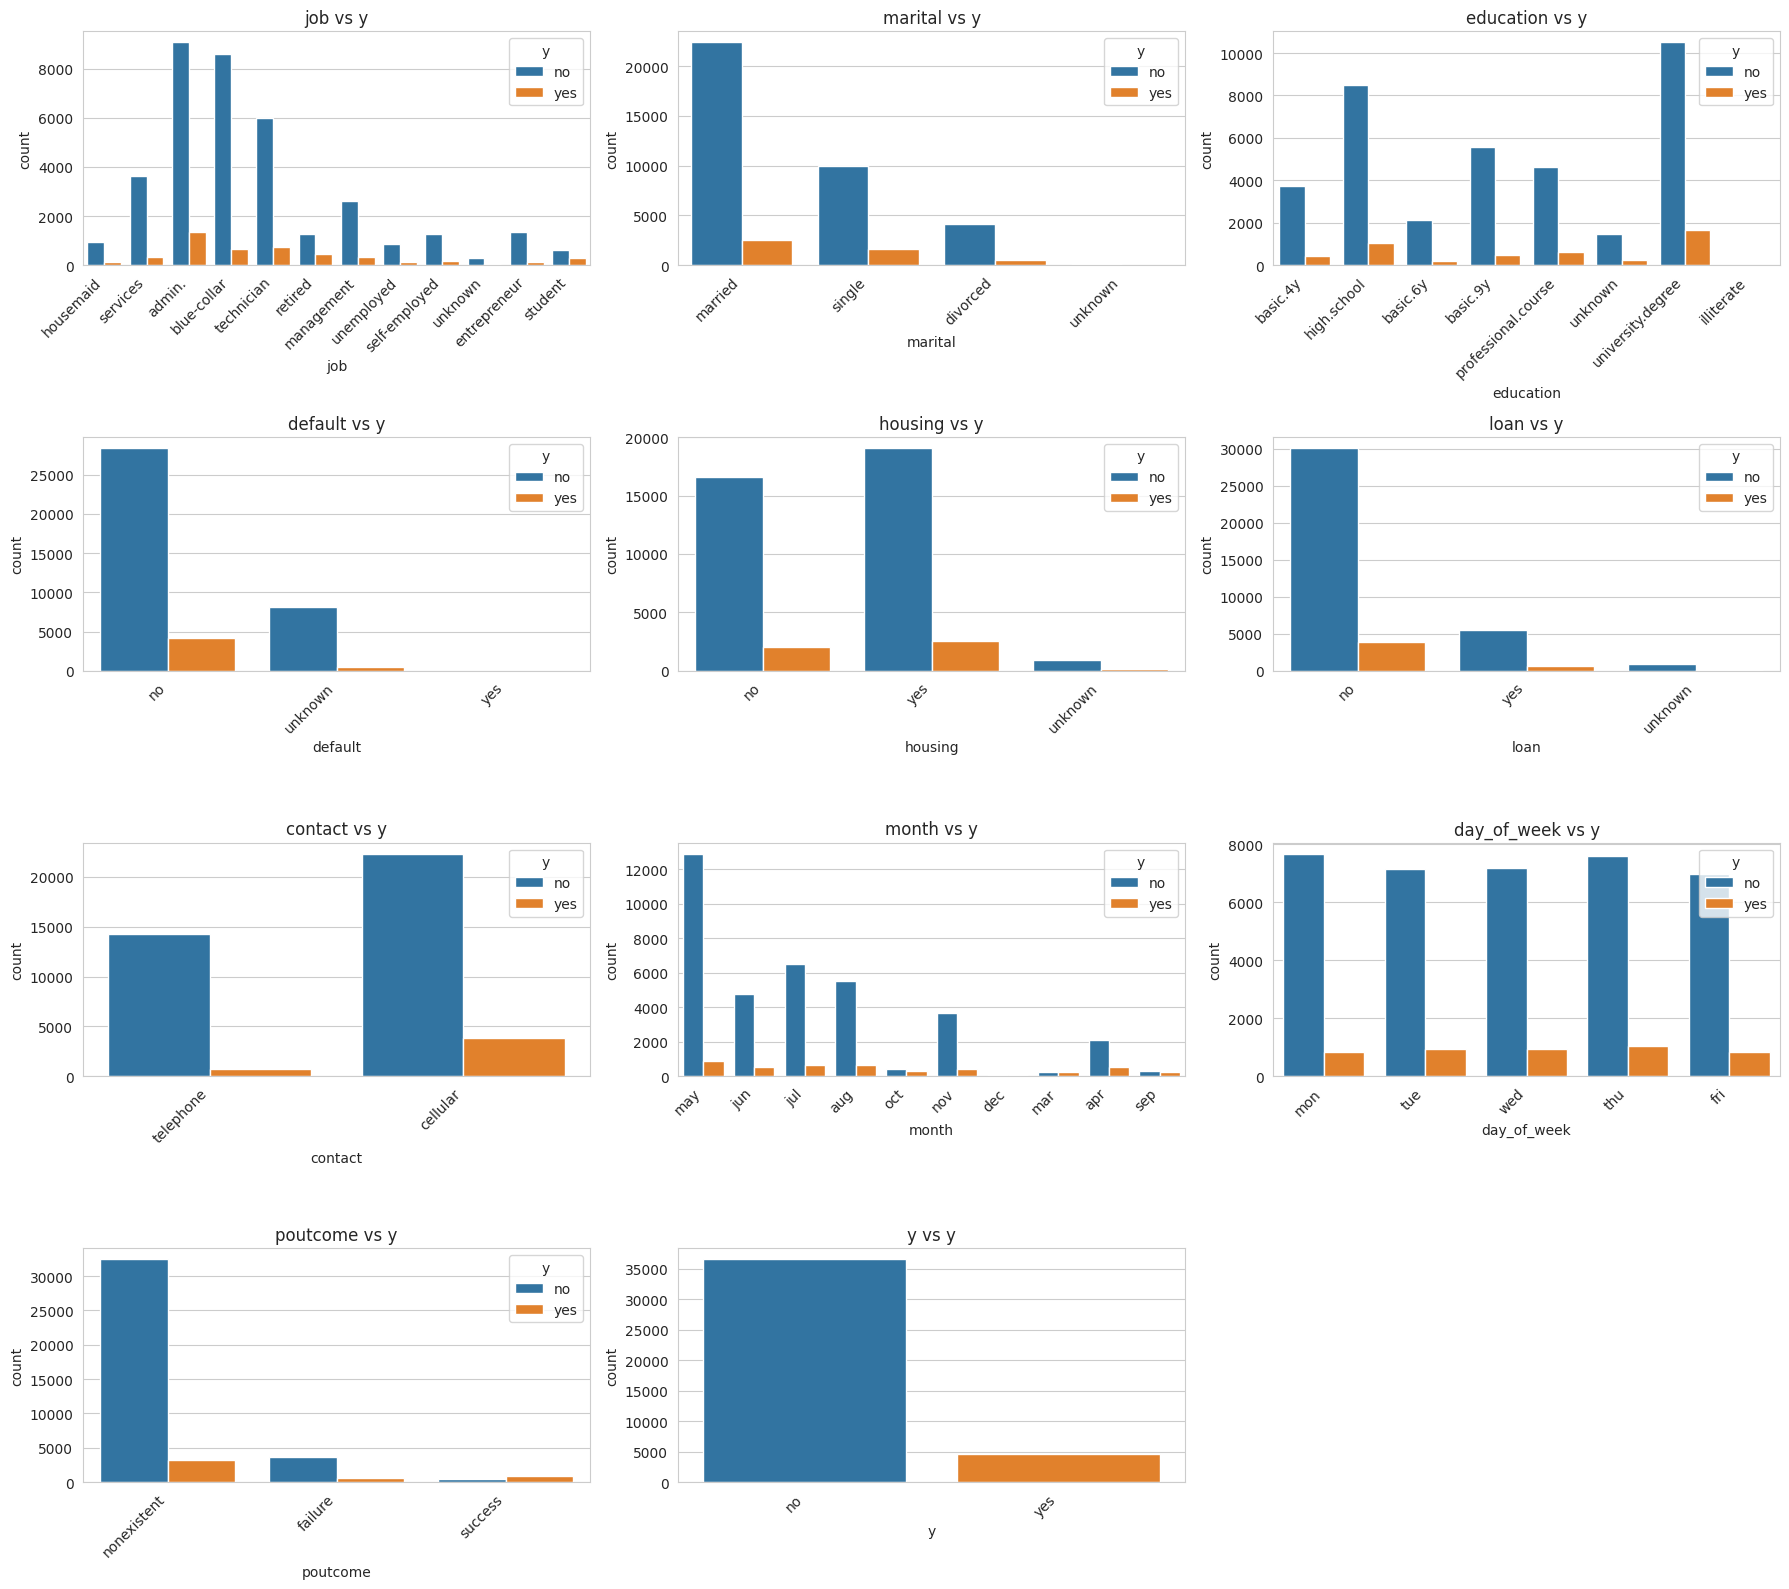

In [15]:
# Countplots of categorical features vs target
plt.figure(figsize=(18, 4 * -(-len(categorical_cols)//3)))
for i, col in enumerate(categorical_cols):
    plt.subplot(-(-len(categorical_cols)//3), 3, i + 1)
    sns.countplot(x=col, hue='y', data=df)
    plt.title(f'{col} vs y'); plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()


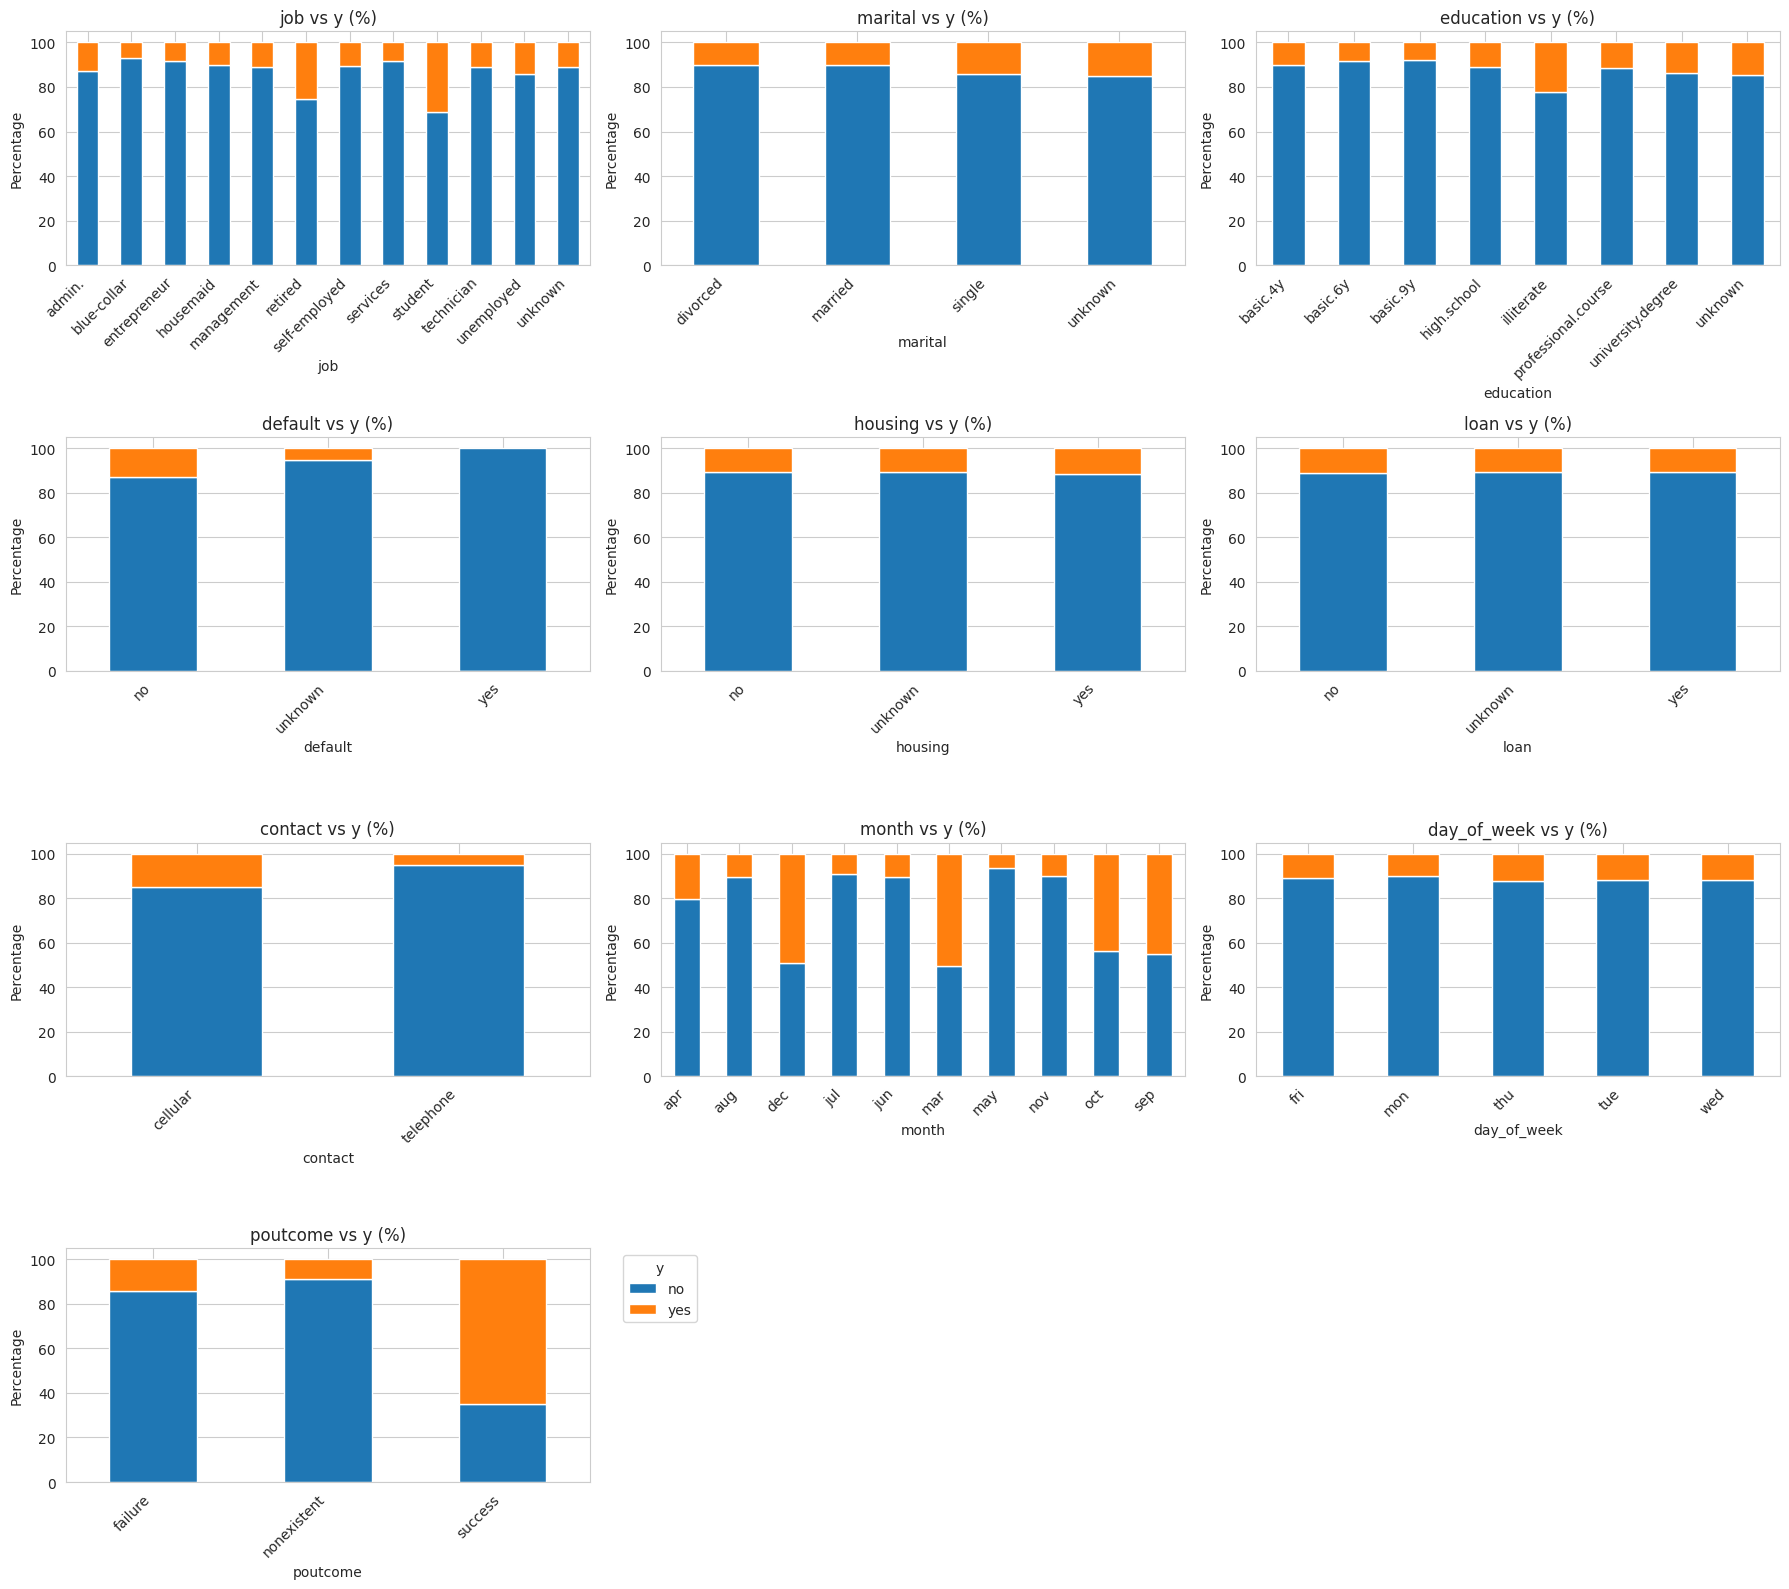

In [16]:

# Stacked bar plots (percentage) for categorical features vs target
plt.figure(figsize=(18, 4 * -(-len(categorical_cols[:-1]) // 3)))
for i, col in enumerate(categorical_cols[:-1]):
    plt.subplot(-(-len(categorical_cols[:-1]) // 3), 3, i + 1)
    pd.crosstab(df[col], df['y'], normalize='index').mul(100).plot(
        kind='bar', stacked=True, ax=plt.gca(), legend=False)
    plt.title(f'{col} vs y (%)')
    plt.ylabel('Percentage')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.legend(title='y', bbox_to_anchor=(1.05, 1))
plt.show()


Chi-Square Test for Categorical Feature Association with Target


In [17]:
for col in categorical_cols[:-1]:
    chi2, p, _, _ = chi2_contingency(pd.crosstab(df[col], df['y']))
    print(f"{col}: p-value = {p:.5f}")


job: p-value = 0.00000
marital: p-value = 0.00000
education: p-value = 0.00000
default: p-value = 0.00000
housing: p-value = 0.05829
loan: p-value = 0.57868
contact: p-value = 0.00000
month: p-value = 0.00000
day_of_week: p-value = 0.00003
poutcome: p-value = 0.00000


## Categorical Feature Association Summary

**Strong Predictors**
- **poutcome, month, contact** → Strongly influence subscription outcome (`y`).
- **poutcome:** Previous success leads to ~65% subscription rate.
- **month:** March, September, October, and December show >40% success; May is the weakest (~6%).
- **contact:** Telephone contact performs slightly better (~15%) than cellular (~9%).

---

**Moderate Predictors**
- **job, marital, education, default, day_of_week** → Show moderate influence.
- Students and retired clients have higher subscription rates; singles perform marginally better.
- Default and day_of_week are statistically significant but have limited practical impact.

---

**Insignificant Predictors**
- **housing, loan** → No meaningful relationship with `y` (p > 0.05).  
- Can be deprioritized or dropped during feature selection.


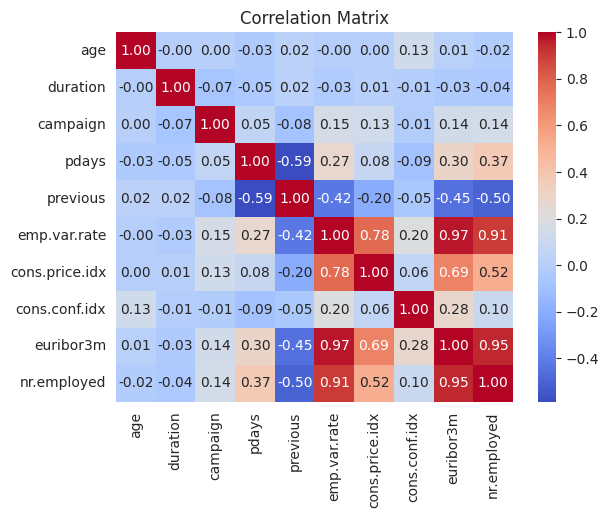

In [18]:
corr = df[numerical_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

## Correlation Insights (Numerical Features)

- **emp.var.rate ↔ euribor3m:** r = 0.97 → Nearly identical; drop one to prevent redundancy.  
- **emp.var.rate ↔ nr.employed:** r = 0.91 → Very high correlation; retain only one.  
- **euribor3m ↔ nr.employed:** r = 0.95 → Strong overlap; redundant information.  
- **cons.price.idx ↔ emp.var.rate:** r = 0.78 → High correlation; monitor for multicollinearity.  
- **cons.price.idx ↔ euribor3m:** r = 0.69 → Moderate–high correlation; consider feature reduction.


#Data Cleaning and Preprocessing
According to EDA , performing data cleaning and preprocessing

Removing redundant features based on multicollineartiy and chi-square scores for significance


In [19]:
features_to_drop = [
    'emp.var.rate',  # Redundant with euribor3m (r=0.97)
    'nr.employed',   # Redundant with euribor3m (r=0.95)
    'loan',          # Insignificant
    'housing'        # Insignificant
]

print(f"Dropping {len(features_to_drop)} features: {features_to_drop}")
df.drop(columns=features_to_drop, inplace=True)

Dropping 4 features: ['emp.var.rate', 'nr.employed', 'loan', 'housing']


Binary Transformation of pdays and default Features

In [20]:
# Convert 'pdays' to binary
df['was_contacted'] = np.where(df['pdays'] != 999, 1, 0)
df.drop(columns=['pdays'], inplace=True)
print("Converted 'pdays' to binary 'was_contacted'. Original column dropped.")

# Simplify 'default' into binary
df['has_default'] = np.where(df['default'] == 'no', 0, 1)
df.drop(columns=['default'], inplace=True)
print("Simplified 'default' into binary 'has_default'. Original column dropped.")


Converted 'pdays' to binary 'was_contacted'. Original column dropped.
Simplified 'default' into binary 'has_default'. Original column dropped.


Target Encoding: Converting y to Binary Labels

In [21]:
# Encode the target 'y' ('no' -> 0, 'yes' -> 1)
df['y_encoded'] = df['y'].map({'no': 0, 'yes': 1})

# Drop the original categorical target column
df.drop(columns=['y'], inplace=True)
print("Encoded target 'y' to 'y_encoded' (0 and 1). Original column dropped.")

Encoded target 'y' to 'y_encoded' (0 and 1). Original column dropped.


Feature Engineering: Interaction Terms

In [22]:
# Create an interaction term: Long Call on Cellular

# Create a combined economic and contact indicator: Favorable_Conditions
# Favorable is low euribor3m (e.g., < 2.0) AND client was contacted before
df['favorable_conditions'] = np.where(
    (df['euribor3m'] < 2.0) & (df['was_contacted'] == 1),
    1,
    0
)
print("Created 'favorable_conditions' interaction features.")

Created 'favorable_conditions' interaction features.


In [23]:
df.head()

,age,job,marital,education,contact,month,day_of_week,duration,campaign,previous,poutcome,cons.price.idx,cons.conf.idx,euribor3m,was_contacted,has_default,y_encoded,favorable_conditions
0,56,housemaid,married,basic.4y,telephone,may,mon,261,1,0,nonexistent,93.994,-36.4,4.857,0,0,0,0
1,57,services,married,high.school,telephone,may,mon,149,1,0,nonexistent,93.994,-36.4,4.857,0,1,0,0
2,37,services,married,high.school,telephone,may,mon,226,1,0,nonexistent,93.994,-36.4,4.857,0,0,0,0
3,40,admin.,married,basic.6y,telephone,may,mon,151,1,0,nonexistent,93.994,-36.4,4.857,0,0,0,0
4,56,services,married,high.school,telephone,may,mon,307,1,0,nonexistent,93.994,-36.4,4.857,0,0,0,0


In [24]:
#Skewness correction and capping
df['campaign_log'] = np.log(df['campaign'])
df.drop(columns=['campaign'], inplace=True)
print("Applied Log Transformation to campaign.")

Applied Log Transformation to campaign.


Capping Outliers for age

In [25]:
age_cap = df['age'].quantile(0.95)
df['age_capped'] = np.where(df['age'] > age_cap, age_cap, df['age'])
df.drop(columns=['age'], inplace=True)
print(f"Capped 'age' outliers at 95th percentile ({age_cap}).")
print("---")

Capped 'age' outliers at 95th percentile (58.0).
---


Addressing data leakage by removing duration


In [26]:
print("Explanation of data leakage with the 'duration' column:")
print("The 'duration' column represents the duration of the last contact with the client in seconds. In a real-world scenario, when you are trying to predict whether a customer will subscribe to a term deposit BEFORE making the contact, you would not know the duration of the contact. Therefore, including 'duration' as a feature in the model training would allow the model to learn from information that is not available at the time of prediction for new customers. This is a form of data leakage, as information from the future ('duration' of a contact that hasn't happened yet) is used to predict an outcome.")
print("\nDropping the 'duration' column...")
df = df.drop('duration', axis=1)
display(df.head())

Explanation of data leakage with the 'duration' column:
The 'duration' column represents the duration of the last contact with the client in seconds. In a real-world scenario, when you are trying to predict whether a customer will subscribe to a term deposit BEFORE making the contact, you would not know the duration of the contact. Therefore, including 'duration' as a feature in the model training would allow the model to learn from information that is not available at the time of prediction for new customers. This is a form of data leakage, as information from the future ('duration' of a contact that hasn't happened yet) is used to predict an outcome.

Dropping the 'duration' column...


,job,marital,education,contact,month,day_of_week,previous,poutcome,cons.price.idx,cons.conf.idx,euribor3m,was_contacted,has_default,y_encoded,favorable_conditions,campaign_log,age_capped
0,housemaid,married,basic.4y,telephone,may,mon,0,nonexistent,93.994,-36.4,4.857,0,0,0,0,0.0,56.0
1,services,married,high.school,telephone,may,mon,0,nonexistent,93.994,-36.4,4.857,0,1,0,0,0.0,57.0
2,services,married,high.school,telephone,may,mon,0,nonexistent,93.994,-36.4,4.857,0,0,0,0,0.0,37.0
3,admin.,married,basic.6y,telephone,may,mon,0,nonexistent,93.994,-36.4,4.857,0,0,0,0,0.0,40.0
4,services,married,high.school,telephone,may,mon,0,nonexistent,93.994,-36.4,4.857,0,0,0,0,0.0,56.0


Remaining features

In [27]:
df.info()
print(df.columns.tolist())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   job                   41188 non-null  object 
 1   marital               41188 non-null  object 
 2   education             41188 non-null  object 
 3   contact               41188 non-null  object 
 4   month                 41188 non-null  object 
 5   day_of_week           41188 non-null  object 
 6   previous              41188 non-null  int64  
 7   poutcome              41188 non-null  object 
 8   cons.price.idx        41188 non-null  float64
 9   cons.conf.idx         41188 non-null  float64
 10  euribor3m             41188 non-null  float64
 11  was_contacted         41188 non-null  int64  
 12  has_default           41188 non-null  int64  
 13  y_encoded             41188 non-null  int64  
 14  favorable_conditions  41188 non-null  int64  
 15  campaign_log       

One Hot Encoding

In [28]:
# Identify remaining object columns
categorical_cols_final = df.select_dtypes(include=['object']).columns.tolist()

# Apply One-Hot Encoding
df = pd.get_dummies(df, columns=categorical_cols_final, drop_first=True, dtype=int)
print(f"Applied One-Hot Encoding to: {categorical_cols_final}")

Applied One-Hot Encoding to: ['job', 'marital', 'education', 'contact', 'month', 'day_of_week', 'poutcome']


StandardScaler

In [29]:
# Define the final numerical features to be scaled
final_numerical_cols_to_scale = [
    'previous',         # Needs scaling
    'cons.price.idx',
    'cons.conf.idx',
    'euribor3m',
    'campaign_log',
    'age_capped'
]

scaler = StandardScaler()
df[final_numerical_cols_to_scale] = scaler.fit_transform(df[final_numerical_cols_to_scale])
print(f"Scaled {len(final_numerical_cols_to_scale)} numerical features.")

Scaled 6 numerical features.


Final Feature Set Definition

In [30]:
# Define target column
target_column = 'y_encoded'

# Final feature sets
final_numerical_cols = [
    'age_capped', 'cons.price.idx', 'cons.conf.idx',
    'euribor3m', 'campaign_log', 'previous'
]

final_categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
final_binary_cols = ['was_contacted', 'has_default', 'favorable_conditions']

final_feature_input_list = (
    final_numerical_cols +
    final_categorical_cols +
    final_binary_cols
)


Final Preprocessing Pipeline

In [31]:

# Define transformers
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
binary_transformer = 'passthrough'

# Define preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num_scaled', numerical_transformer, final_numerical_cols),
        ('cat_encoded', categorical_transformer, final_categorical_cols),
        ('bin_pass', binary_transformer, final_binary_cols)
    ],
    remainder='drop'
)

# Define final model pipeline (placeholder)
final_preprocessing_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor)
])

print("Final Preprocessing Pipeline constructed successfully!")


Final Preprocessing Pipeline constructed successfully!


#Data Splitting

In [32]:
# Define features and target
X = df.drop(columns=['y_encoded'])
y = df['y_encoded']

# Split data into training and testing sets (75% train, 25% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("Data Split Complete:")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")


Data Split Complete:
X_train shape: (30891, 46), y_train shape: (30891,)
X_test shape: (10297, 46), y_test shape: (10297,)


In [33]:
# Apply the pipeline to the training data (fit_transform) and test data (transform)
X_train_processed = final_preprocessing_pipeline.fit_transform(X_train)
X_test_processed = final_preprocessing_pipeline.transform(X_test)

print(f"\nPreprocessing Complete:")
print(f"X_train_processed shape: {X_train_processed.shape}")
print(f"X_test_processed shape: {X_test_processed.shape}")


Preprocessing Complete:
X_train_processed shape: (30891, 9)
X_test_processed shape: (10297, 9)


Handling Class Imbalance(SMOTE)

In [34]:
# Instantiate SMOTE
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train_processed, y_train)

print(f"Original training shape: {X_train_processed.shape}")
print(f"SMOTE training shape: {X_train_smote.shape}")
print(f"Target distribution after SMOTE:\n{y_train_smote.value_counts()}")

Original training shape: (30891, 9)
SMOTE training shape: (54822, 9)
Target distribution after SMOTE:
y_encoded
0    27411
1    27411
Name: count, dtype: int64


#Model Training and Evaluation

**Logistic Regression**

In [35]:


model = LogisticRegression(random_state=42, max_iter=500)
model.fit(X_train_smote, y_train_smote)
y_pred = model.predict(X_test_processed)
y_proba = model.predict_proba(X_test_processed)[:, 1]

print("\n--- Baseline Model Evaluation (Logistic Regression) ---")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))



--- Baseline Model Evaluation (Logistic Regression) ---
              precision    recall  f1-score   support

           0       0.95      0.76      0.85      9137
           1       0.27      0.71      0.40      1160

    accuracy                           0.76     10297
   macro avg       0.61      0.73      0.62     10297
weighted avg       0.88      0.76      0.80     10297

ROC-AUC Score: 0.7750

Confusion Matrix:
[[6977 2160]
 [ 341  819]]


**Decision Tree Classifier**

In [41]:
# --- Decision Tree Model with Preprocessing Pipeline ---

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# 1. Build full pipeline (Preprocessor + Classifier)
dt_classifier_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5,
    class_weight='balanced'
)

final_model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', dt_classifier_model)
])

# 2. Train model
final_model_pipeline.fit(X_train, y_train)
print("Decision Tree model trained successfully.")

# 3. Evaluate on test data
y_pred_pipe = final_model_pipeline.predict(X_test)
y_proba_pipe = final_model_pipeline.predict_proba(X_test)[:, 1]

print("\n--- Model Evaluation ---")
print(classification_report(y_test, y_pred_pipe, target_names=['No', 'Yes']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba_pipe):.4f}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred_pipe)}")
try:
  # 4. Prepare feature names for visualization
  fitted_preprocessor = final_model_pipeline['preprocessor']
  fitted_dt = final_model_pipeline['classifier']

  # Manually fit preprocessor to extract feature names
  fitted_preprocessor.fit(X_train)

  scaled_names = fitted_preprocessor.transformers_[0][2]
  ohe_names = fitted_preprocessor.named_transformers_['cat_encoded'].get_feature_names_out()
  bin_pass_names = fitted_preprocessor.transformers_[2][2]

  final_feature_names_list = np.concatenate([
      scaled_names, ohe_names, bin_pass_names
  ]).tolist()

  # 5. Plot Decision Tree
  plt.figure(figsize=(25, 12))
  plot_tree(
      fitted_dt,
      max_depth=3,
      feature_names=final_feature_names_list,
      class_names=['no', 'yes'],
      filled=True,
      rounded=True,
      fontsize=8
  )
  plt.title("Decision Tree Classifier (max_depth=3)")
  plt.show()
except Exception:
  pass


Decision Tree model trained successfully.

--- Model Evaluation ---
              precision    recall  f1-score   support

          No       0.95      0.86      0.90      9137
         Yes       0.37      0.65      0.47      1160

    accuracy                           0.83     10297
   macro avg       0.66      0.75      0.68     10297
weighted avg       0.88      0.83      0.85     10297

ROC-AUC Score: 0.8036
Confusion Matrix:
[[7839 1298]
 [ 409  751]]


**KNN Classifier**


In [42]:
# Instantiate KNN Classifier with k=5 neighbors
knn_classifier = KNeighborsClassifier(n_neighbors=5)

# Integrate the preprocessor and the classifier into the final pipeline
final_knn_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', knn_classifier)
])

# Fit the full pipeline on the original training data
final_knn_pipeline.fit(X_train, y_train)
print("KNN Model trained successfully on the full pipeline.")

KNN Model trained successfully on the full pipeline.


In [43]:
# Predict on the UNSEEN test set
y_pred_knn = final_knn_pipeline.predict(X_test)
y_proba_knn = final_knn_pipeline.predict_proba(X_test)[:, 1]

# Evaluate and print results
print("\n--- KNN Model Evaluation (k=5) ---")
print(classification_report(y_test, y_pred_knn, target_names=['No', 'Yes']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba_knn):.4f}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred_knn)}")


--- KNN Model Evaluation (k=5) ---
              precision    recall  f1-score   support

          No       0.91      0.97      0.94      9137
         Yes       0.54      0.27      0.36      1160

    accuracy                           0.89     10297
   macro avg       0.73      0.62      0.65     10297
weighted avg       0.87      0.89      0.88     10297

ROC-AUC Score: 0.7296
Confusion Matrix:
[[8873  264]
 [ 845  315]]


**MultiLayer Perceptron**


In [44]:
# MLP Classifier with Preprocessing Pipeline

mlp_classifier = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    max_iter=500,
    random_state=42,
    solver='adam',
    early_stopping=True
)

final_mlp_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', mlp_classifier)
])

final_mlp_pipeline.fit(X_train, y_train)

y_pred_mlp = final_mlp_pipeline.predict(X_test)
y_proba_mlp = final_mlp_pipeline.predict_proba(X_test)[:, 1]

print("\n--- MLP Model Evaluation ---")
print(classification_report(y_test, y_pred_mlp, target_names=['No', 'Yes']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba_mlp):.4f}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred_mlp)}")



--- MLP Model Evaluation ---
              precision    recall  f1-score   support

          No       0.91      0.99      0.95      9137
         Yes       0.69      0.22      0.34      1160

    accuracy                           0.90     10297
   macro avg       0.80      0.61      0.64     10297
weighted avg       0.88      0.90      0.88     10297

ROC-AUC Score: 0.7982
Confusion Matrix:
[[9020  117]
 [ 901  259]]


**Naïve bayes**




In [45]:
# Gaussian Naive Bayes Classifier with Preprocessing Pipeline

gnb_classifier = GaussianNB()

final_gnb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', gnb_classifier)
])

final_gnb_pipeline.fit(X_train, y_train)

y_pred_gnb = final_gnb_pipeline.predict(X_test)
y_proba_gnb = final_gnb_pipeline.predict_proba(X_test)[:, 1]

print("\n--- Gaussian Naive Bayes Model Evaluation ---")
print(classification_report(y_test, y_pred_gnb, target_names=['No', 'Yes']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba_gnb):.4f}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred_gnb)}")



--- Gaussian Naive Bayes Model Evaluation ---
              precision    recall  f1-score   support

          No       0.91      0.97      0.94      9137
         Yes       0.50      0.24      0.33      1160

    accuracy                           0.89     10297
   macro avg       0.71      0.61      0.63     10297
weighted avg       0.86      0.89      0.87     10297

ROC-AUC Score: 0.7608
Confusion Matrix:
[[8858  279]
 [ 877  283]]


**Support vector machine**



In [46]:
# Linear SVC Classifier with Preprocessing Pipeline

lsvc_classifier = LinearSVC(
    random_state=42,
    class_weight='balanced',
    dual=False
)

final_lsvc_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', lsvc_classifier)
])

final_lsvc_pipeline.fit(X_train, y_train)

y_pred_lsvc = final_lsvc_pipeline.predict(X_test)
y_scores_lsvc = final_lsvc_pipeline.decision_function(X_test)

print("\n--- Linear SVC Model Evaluation ---")
print(classification_report(y_test, y_pred_lsvc, target_names=['No', 'Yes']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_scores_lsvc):.4f}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred_lsvc)}")



--- Linear SVC Model Evaluation ---
              precision    recall  f1-score   support

          No       0.96      0.74      0.84      9137
         Yes       0.26      0.73      0.39      1160

    accuracy                           0.74     10297
   macro avg       0.61      0.74      0.61     10297
weighted avg       0.88      0.74      0.79     10297

ROC-AUC Score: 0.7739
Confusion Matrix:
[[6790 2347]
 [ 314  846]]


**Random Forest**

In [47]:
# Random Forest Classifier with Preprocessing Pipeline

rf_classifier = RandomForestClassifier(
    n_estimators=100,
    max_depth=50,
    random_state=42,
    class_weight='balanced'
)

final_rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', rf_classifier)
])

final_rf_pipeline.fit(X_train, y_train)

y_pred_rf = final_rf_pipeline.predict(X_test)
y_proba_rf = final_rf_pipeline.predict_proba(X_test)[:, 1]

print("\n--- Random Forest Model Evaluation ---")
print(classification_report(y_test, y_pred_rf, target_names=['No', 'Yes']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba_rf):.4f}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred_rf)}")



--- Random Forest Model Evaluation ---
              precision    recall  f1-score   support

          No       0.92      0.91      0.91      9137
         Yes       0.33      0.36      0.35      1160

    accuracy                           0.85     10297
   macro avg       0.63      0.63      0.63     10297
weighted avg       0.85      0.85      0.85     10297

ROC-AUC Score: 0.7289
Confusion Matrix:
[[8306  831]
 [ 743  417]]


**XGBOOST**

In [48]:
# XGBoost Classifier with Imbalance Handling

neg_count = y_train.value_counts()[0]
pos_count = y_train.value_counts()[1]
scale_pos_weight_value = neg_count / pos_count
print(f"scale_pos_weight: {scale_pos_weight_value:.2f}")

xgb_classifier = xgb.XGBClassifier(
    objective='binary:logistic',
    use_label_encoder=False,
    eval_metric='logloss',
    n_estimators=100,
    random_state=42,
    scale_pos_weight=scale_pos_weight_value
)

final_xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', xgb_classifier)
])

final_xgb_pipeline.fit(X_train, y_train)

y_pred_xgb = final_xgb_pipeline.predict(X_test)
y_proba_xgb = final_xgb_pipeline.predict_proba(X_test)[:, 1]

print("\n--- XGBoost Model Evaluation ---")
print(classification_report(y_test, y_pred_xgb, target_names=['No', 'Yes']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba_xgb):.4f}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred_xgb)}")


scale_pos_weight: 7.88

--- XGBoost Model Evaluation ---
              precision    recall  f1-score   support

          No       0.95      0.86      0.90      9137
         Yes       0.36      0.62      0.45      1160

    accuracy                           0.83     10297
   macro avg       0.65      0.74      0.68     10297
weighted avg       0.88      0.83      0.85     10297

ROC-AUC Score: 0.7847
Confusion Matrix:
[[7840 1297]
 [ 439  721]]


##Comparing Metrics of each model

In [49]:
# Model Performance Comparison Across All Classifiers

accuracy_dt = accuracy_score(y_test, y_pred_pipe)
precision_dt = precision_score(y_test, y_pred_pipe)
recall_dt = recall_score(y_test, y_pred_pipe)
f1_dt = f1_score(y_test, y_pred_pipe)

accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)

accuracy_gnb = accuracy_score(y_test, y_pred_gnb)
precision_gnb = precision_score(y_test, y_pred_gnb)
recall_gnb = recall_score(y_test, y_pred_gnb)
f1_gnb = f1_score(y_test, y_pred_gnb)

accuracy_svm = accuracy_score(y_test, y_pred_lsvc)
precision_svm = precision_score(y_test, y_pred_lsvc)
recall_svm = recall_score(y_test, y_pred_lsvc)
f1_svm = f1_score(y_test, y_pred_lsvc)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

performance_metrics = {
    'Model': ['Decision Tree', 'KNN', 'Naive Bayes', 'SVM', 'Random Forest', 'XGBoost'],
    'Accuracy': [accuracy_dt, accuracy_knn, accuracy_gnb, accuracy_svm, accuracy_rf, accuracy_xgb],
    'Precision': [precision_dt, precision_knn, precision_gnb, precision_svm, precision_rf, precision_xgb],
    'Recall': [recall_dt, recall_knn, recall_gnb, recall_svm, recall_rf, recall_xgb],
    'F1-score': [f1_dt, f1_knn, f1_gnb, f1_svm, f1_rf, f1_xgb]
}

performance_df = pd.DataFrame(performance_metrics)
for col in ['Accuracy', 'Precision', 'Recall', 'F1-score']:
    performance_df[col] = performance_df[col].apply(lambda x: f'{x:.4f}')

display(performance_df)

best_f1_idx = performance_df['F1-score'].astype(float).idxmax()
print(f"Best Model: {performance_df.loc[best_f1_idx, 'Model']} "
      f"with F1-score = {performance_df.loc[best_f1_idx, 'F1-score']}")


,Model,Accuracy,Precision,Recall,F1-score
0,Decision Tree,0.8342,0.3665,0.6474,0.4681
1,KNN,0.8923,0.5440,0.2716,0.3623
2,Naive Bayes,0.8877,0.5036,0.2440,0.3287
3,SVM,0.7416,0.2650,0.7293,0.3887
4,Random Forest,0.8471,0.3341,0.3595,0.3463
5,XGBoost,0.8314,0.3573,0.6216,0.4537


Best Model: Decision Tree with F1-score = 0.4681


Using F1 score to choose best model, because dataset is imbalanced for yes and no outpit , using F1 balances properly between recall and precision.Therefore for tuning I chose Decision tree and XGBoost

##Hyper Parameter Tuning

**Tuning Decision Tree**

In [50]:
# Decision Tree F1-score tuning using GridSearchCV
param_grid = {
    'classifier__max_depth': [5, 7, 10, 15],
    'classifier__min_samples_split': [10, 20, 30],
    'classifier__min_samples_leaf': [5, 10, 15]
}

dt_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42, class_weight='balanced'))
])

f1_scorer = make_scorer(f1_score, pos_label=1)

grid_search = GridSearchCV(
    estimator=dt_pipeline,
    param_grid=param_grid,
    scoring=f1_scorer,
    cv=5,
    verbose=2,
    n_jobs=-1
)


In [51]:
# Fit and evaluate tuned Decision Tree
grid_search.fit(X_train, y_train)

print("\n--- GridSearchCV Results ---")
print(f"Best F1-Score: {grid_search.best_score_:.4f}")
print("Best Parameters:", grid_search.best_params_)

best_dt_model = grid_search.best_estimator_
y_pred_tuned = best_dt_model.predict(X_test)
y_proba_tuned = best_dt_model.predict_proba(X_test)[:, 1]

print("\n--- Tuned Decision Tree Evaluation ---")
print(classification_report(y_test, y_pred_tuned, target_names=['No', 'Yes']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba_tuned):.4f}")


Fitting 5 folds for each of 36 candidates, totalling 180 fits

--- GridSearchCV Results ---
Best F1-Score: 0.4482
Best Parameters: {'classifier__max_depth': 7, 'classifier__min_samples_leaf': 5, 'classifier__min_samples_split': 30}

--- Tuned Decision Tree Evaluation ---
              precision    recall  f1-score   support

          No       0.95      0.85      0.90      9137
         Yes       0.36      0.65      0.47      1160

    accuracy                           0.83     10297
   macro avg       0.66      0.75      0.68     10297
weighted avg       0.88      0.83      0.85     10297

ROC-AUC Score: 0.8088


**Tuning XGBoost**

In [52]:
# Tune and evaluate XGBoost
neg_count = y_train.value_counts()[0]
pos_count = y_train.value_counts()[1]
scale_pos_weight_value = neg_count / pos_count

param_grid_xgb = {
    'classifier__max_depth': [3, 5, 7],
    'classifier__learning_rate': [0.05, 0.1, 0.2],
    'classifier__n_estimators': [100, 200],
}

xgb_classifier_model = xgb.XGBClassifier(
    objective='binary:logistic',
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    scale_pos_weight=scale_pos_weight_value
)

xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', xgb_classifier_model)
])

f1_scorer = make_scorer(f1_score, pos_label=1)

grid_search_xgb = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid_xgb,
    scoring=f1_scorer,
    cv=5,
    verbose=1,
    n_jobs=-1
)

grid_search_xgb.fit(X_train, y_train)

print("\n--- Tuned XGBoost Results ---")
print(f"Best F1-Score: {grid_search_xgb.best_score_:.4f}")
print("Best Params:", grid_search_xgb.best_params_)

best_xgb_model = grid_search_xgb.best_estimator_
y_pred_xgb_tuned = best_xgb_model.predict(X_test)

print("\n--- Tuned XGBoost Evaluation ---")
print(classification_report(y_test, y_pred_xgb_tuned, target_names=['No', 'Yes']))


Fitting 5 folds for each of 18 candidates, totalling 90 fits

--- Tuned XGBoost Results ---
Best F1-Score: 0.4589
Best Params: {'classifier__learning_rate': 0.05, 'classifier__max_depth': 7, 'classifier__n_estimators': 100}

--- Tuned XGBoost Evaluation ---
              precision    recall  f1-score   support

          No       0.95      0.87      0.91      9137
         Yes       0.39      0.65      0.48      1160

    accuracy                           0.84     10297
   macro avg       0.67      0.76      0.70     10297
weighted avg       0.89      0.84      0.86     10297



##Choosing best model after tuning

In [53]:
# Final metrics comparison for tuned models

# Decision Tree
y_proba_dt_tuned = best_dt_model.predict_proba(X_test)[:, 1]
accuracy_dt_tuned = accuracy_score(y_test, y_pred_tuned)
precision_dt_tuned = precision_score(y_test, y_pred_tuned)
recall_dt_tuned = recall_score(y_test, y_pred_tuned)
f1_dt_tuned = f1_score(y_test, y_pred_tuned)
roc_auc_dt_tuned = roc_auc_score(y_test, y_proba_tuned)

# XGBoost
y_proba_xgb_tuned = best_xgb_model.predict_proba(X_test)[:, 1]
accuracy_xgb_tuned = accuracy_score(y_test, y_pred_xgb_tuned)
precision_xgb_tuned = precision_score(y_test, y_pred_xgb_tuned)
recall_xgb_tuned = recall_score(y_test, y_pred_xgb_tuned)
f1_xgb_tuned = f1_score(y_test, y_pred_xgb_tuned)
roc_auc_xgb_tuned = roc_auc_score(y_test, y_proba_xgb_tuned)

# Comparison DataFrame
performance_metrics_tuned = {
    'Model': ['Tuned Decision Tree', 'Tuned XGBoost'],
    'Accuracy': [accuracy_dt_tuned, accuracy_xgb_tuned],
    'Precision (Yes)': [precision_dt_tuned, precision_xgb_tuned],
    'Recall (Yes)': [recall_dt_tuned, recall_xgb_tuned],
    'F1-score (Yes)': [f1_dt_tuned, f1_xgb_tuned],
    'ROC-AUC Score': [roc_auc_dt_tuned, roc_auc_xgb_tuned]
}

performance_df_tuned = pd.DataFrame(performance_metrics_tuned)
performance_df_display = performance_df_tuned.copy()
for col in performance_df_display.columns.drop('Model'):
    performance_df_display[col] = performance_df_display[col].apply(lambda x: f'{x:.4f}')

print("\n--- Final Tuned Model Performance ---")
display(performance_df_display)

# Determine final best model
best_f1_idx = performance_df_tuned['F1-score (Yes)'].idxmax()
print("\nBest Final Model:")
print(f"Model: {performance_df_tuned.loc[best_f1_idx, 'Model']}")
print(f"F1-score: {performance_df_tuned.loc[best_f1_idx, 'F1-score (Yes)']:.4f}")
print(f"ROC-AUC: {performance_df_tuned.loc[best_f1_idx, 'ROC-AUC Score']:.4f}")



--- Final Tuned Model Performance ---


,Model,Accuracy,Precision (Yes),Recall (Yes),F1-score (Yes),ROC-AUC Score
0,Tuned Decision Tree,0.8313,0.3618,0.6509,0.4650,0.8088
1,Tuned XGBoost,0.8438,0.3851,0.6474,0.4830,0.8066



Best Final Model:
Model: Tuned XGBoost
F1-score: 0.4830
ROC-AUC: 0.8066


# ***Final predictions using Tuned XGBoost***


In [54]:
# Final predictions using tuned XGBoost
final_model = best_xgb_model
final_y_pred = final_model.predict(X_test)
final_y_proba = final_model.predict_proba(X_test)[:, 1]

results_df = X_test.copy()
results_df['Actual_y'] = y_test
results_df['Predicted_y'] = final_y_pred
results_df['Subscription_Probability'] = final_y_proba

print("\n--- Tuned XGBoost Final Predictions (Top 10) ---")
display(results_df[['Actual_y', 'Predicted_y', 'Subscription_Probability']].head(10))



--- Tuned XGBoost Final Predictions (Top 10) ---


,Actual_y,Predicted_y,Subscription_Probability
31165,1,0,0.400164
26855,0,0,0.389152
38292,0,1,0.732995
8532,0,0,0.275654
25472,0,0,0.342090
21627,0,0,0.183751
12426,0,0,0.355044
17786,0,0,0.223279
24414,0,0,0.305433
24821,0,0,0.281728


#Saving model

In [56]:
# Save the tuned XGBoost pipeline model
MODEL_PATH = 'final_subscription_predictor_pipeline.pkl'
final_model_to_save = best_xgb_model


with open(MODEL_PATH, 'wb') as file:
        pickle.dump(final_model_to_save, file)

